<a href="https://www.kaggle.com/code/lalit7881/smartphone-usage-addiction-dataset?scriptVersionId=304475978" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/guriya79/smart-phone/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


## Loading dataset

In [2]:
file_path = "/kaggle/input/datasets/guriya79/smart-phone/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"

df = pd.read_csv(file_path)

In [3]:
df.head()          # First 5 rows
df.tail()          # Last 5 rows
df.shape           # Rows & columns
df.columns         # Column names
df.info()          # Data types & nulls
df.describe()      # Statistical summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [4]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [5]:
df = df.dropna()  # or use fillna()
# df.fillna(method='ffill', inplace=True)

In [6]:
df = df.drop_duplicates()

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [8]:
df.corr(numeric_only=True)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
age,1.000000,0.012363,-0.003035,-0.018187,-0.025279,-0.005701,0.001593,-0.008219,0.014938,0.000866
daily_screen_time_hours,0.012363,1.000000,-0.092602,-0.000492,0.005023,0.014112,0.000989,0.025465,0.961814,0.470922
social_media_hours,-0.003035,-0.092602,1.000000,-0.003062,0.004201,0.004473,-0.007034,0.002754,-0.086821,0.364315
gaming_hours,-0.018187,-0.000492,-0.003062,1.000000,0.007245,-0.008201,0.016110,-0.007268,-0.008730,0.009012
work_study_hours,-0.025279,0.005023,0.004201,0.007245,1.000000,-0.027805,-0.016364,-0.028972,0.008048,0.003976
sleep_hours,-0.005701,0.014112,0.004473,-0.008201,-0.027805,1.000000,0.013852,0.017247,0.013014,0.033541
notifications_per_day,0.001593,0.000989,-0.007034,0.016110,-0.016364,0.013852,1.000000,0.003222,-0.003674,-0.000449
app_opens_per_day,-0.008219,0.025465,0.002754,-0.007268,-0.028972,0.017247,0.003222,1.000000,0.020311,0.010357
weekend_screen_time,0.014938,0.961814,-0.086821,-0.008730,0.008048,0.013014,-0.003674,0.020311,1.000000,0.450017
addicted_label,0.000866,0.470922,0.364315,0.009012,0.003976,0.033541,-0.000449,0.010357,0.450017,1.000000


In [9]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [10]:
df.nunique()

transaction_id             6681
user_id                    6681
age                          18
gender                        3
daily_screen_time_hours     898
social_media_hours          551
gaming_hours                401
work_study_hours            551
sleep_hours                 451
notifications_per_day       231
app_opens_per_day           166
weekend_screen_time        1081
stress_level                  3
academic_work_impact          2
addiction_level               3
addicted_label                2
dtype: int64

In [11]:
df.isnull().sum()

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(6681, 16)

In [14]:
df.dtypes

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

## EDA

In [15]:
sns.set(style="whitegrid")

In [16]:
colors = ["#FF6F61", "#6B5B95", "#88B04B", "#F7CAC9", "#92A8D1", "#955251"]

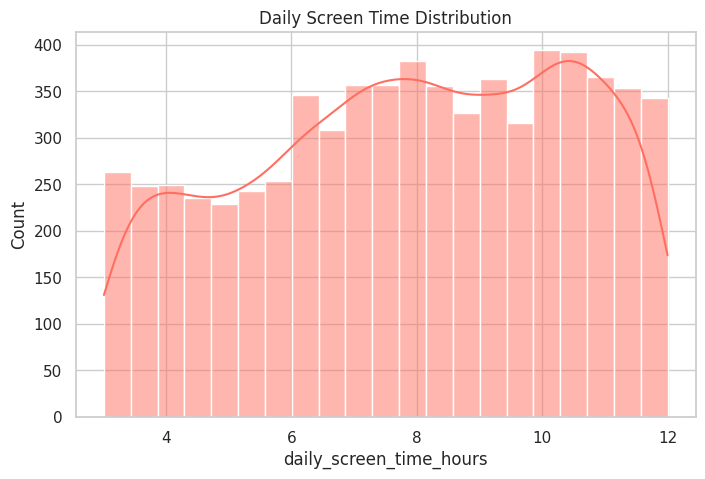

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_screen_time_hours'], kde=True, color=colors[0])
plt.title("Daily Screen Time Distribution")
plt.show()

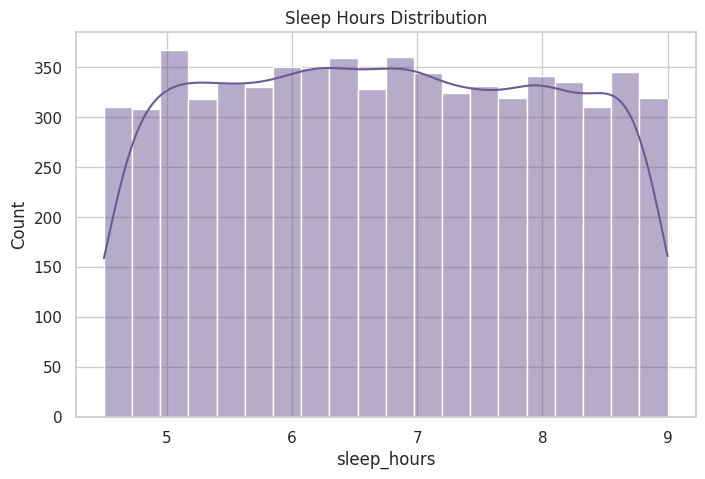

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['sleep_hours'], kde=True, color=colors[1])
plt.title("Sleep Hours Distribution")
plt.show()

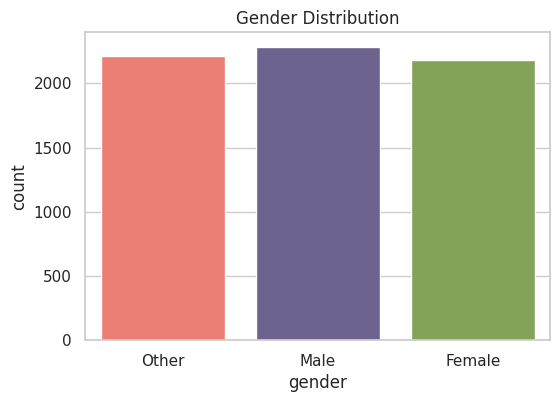

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df, palette=colors)
plt.title("Gender Distribution")
plt.show()

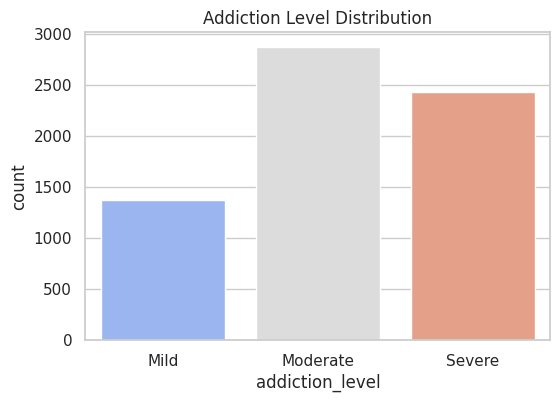

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='addiction_level', data=df, palette="coolwarm")
plt.title("Addiction Level Distribution")
plt.show()

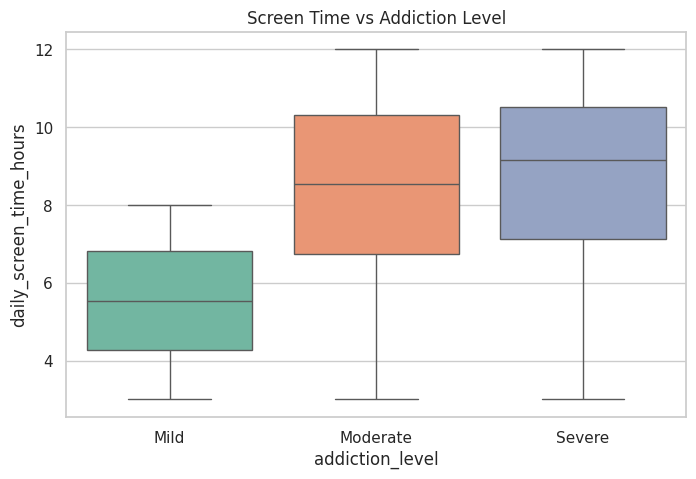

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='addiction_level', y='daily_screen_time_hours', data=df, palette="Set2")
plt.title("Screen Time vs Addiction Level")
plt.show()

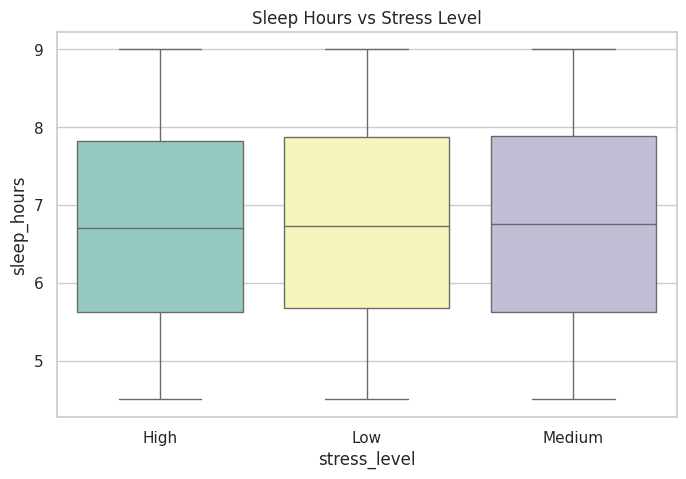

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stress_level', y='sleep_hours', data=df, palette="Set3")
plt.title("Sleep Hours vs Stress Level")
plt.show()

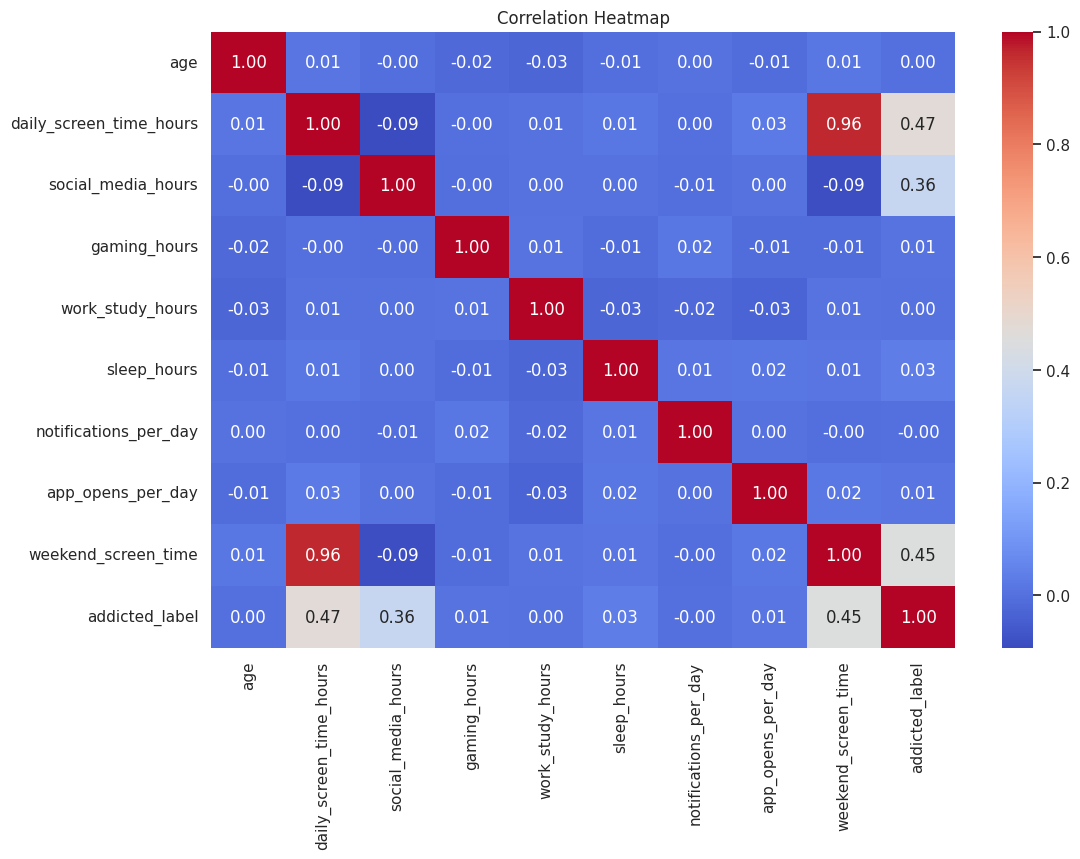

In [23]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

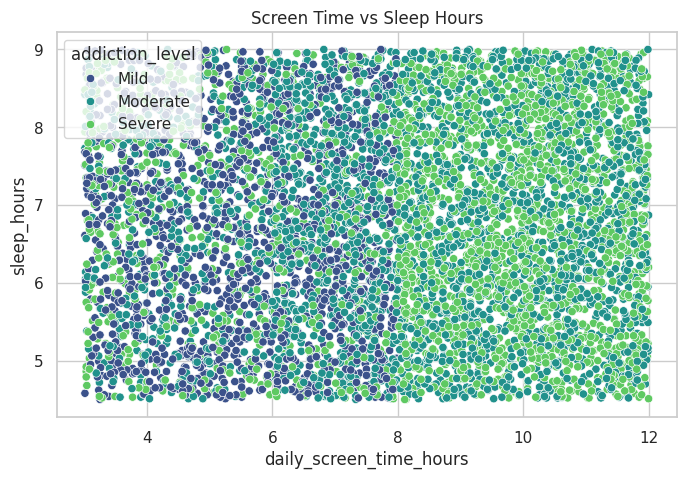

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='daily_screen_time_hours',
    y='sleep_hours',
    hue='addiction_level',
    palette="viridis",
    data=df
)
plt.title("Screen Time vs Sleep Hours")
plt.show()

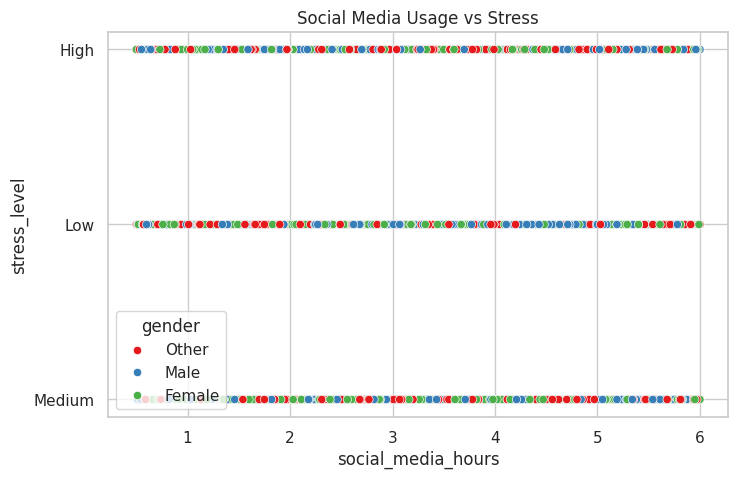

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='social_media_hours',
    y='stress_level',
    hue='gender',
    palette="Set1",
    data=df
)
plt.title("Social Media Usage vs Stress")
plt.show()

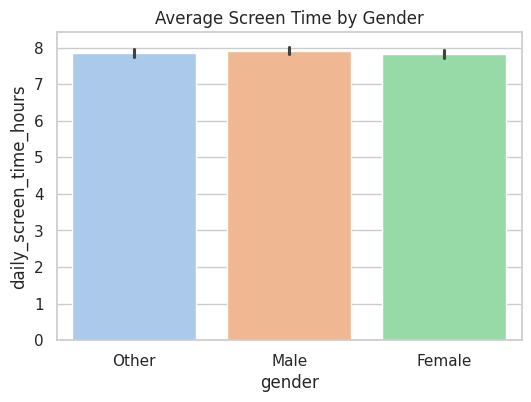

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='gender',
    y='daily_screen_time_hours',
    data=df,
    palette="pastel"
)
plt.title("Average Screen Time by Gender")
plt.show()

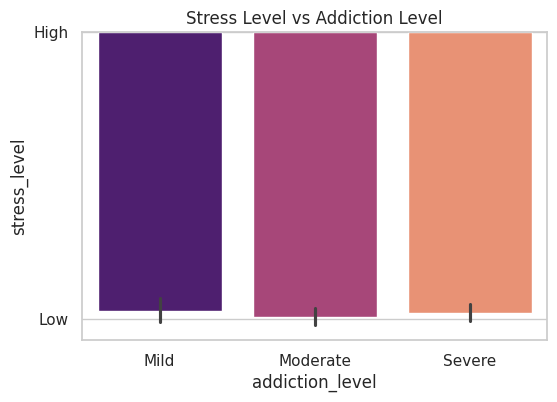

In [27]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='addiction_level',
    y='stress_level',
    data=df,
    palette="magma"
)
plt.title("Stress Level vs Addiction Level")
plt.show()

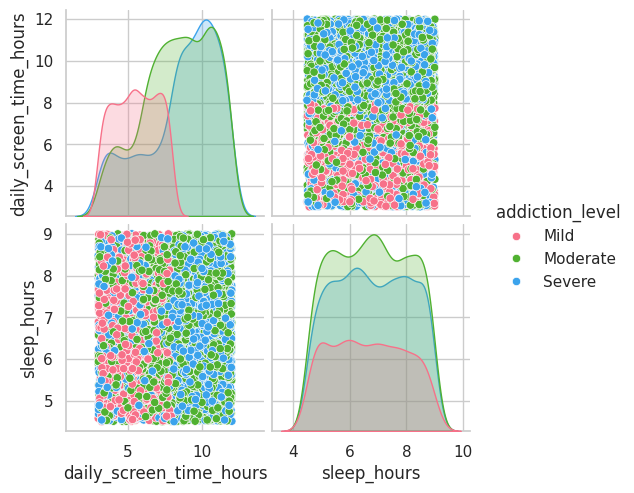

In [28]:
sns.pairplot(
    df[['daily_screen_time_hours', 'sleep_hours', 'stress_level', 'addiction_level']],
    hue='addiction_level',
    palette="husl"
)
plt.show()

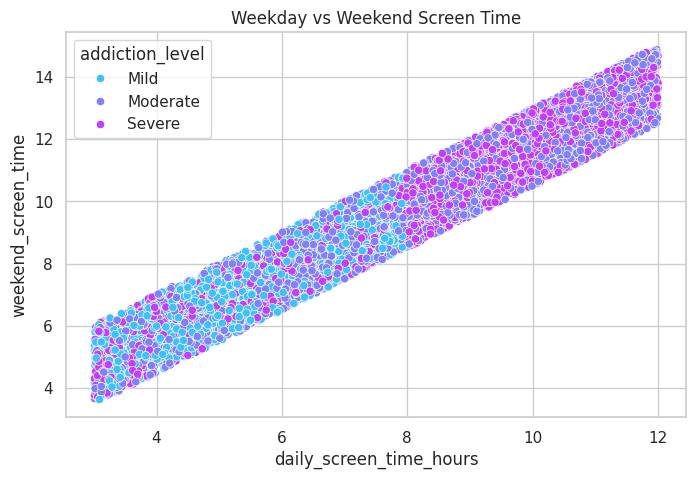

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='daily_screen_time_hours',
    y='weekend_screen_time',
    hue='addiction_level',
    palette="cool",
    data=df
)
plt.title("Weekday vs Weekend Screen Time")
plt.show()

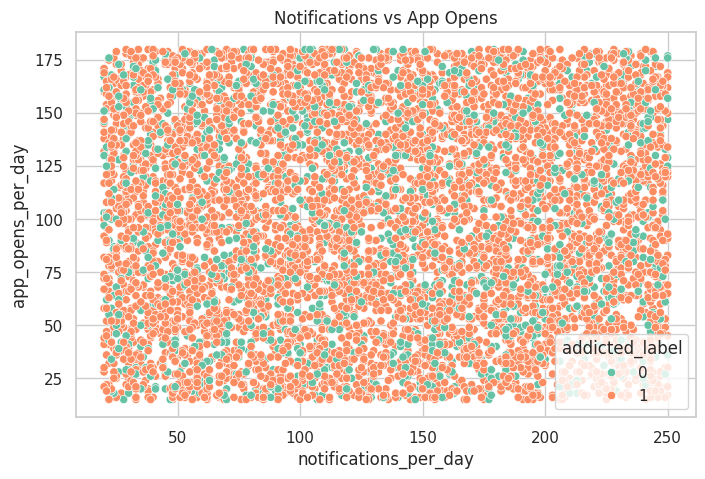

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='notifications_per_day',
    y='app_opens_per_day',
    hue='addicted_label',
    palette="Set2",
    data=df
)
plt.title("Notifications vs App Opens")
plt.show()

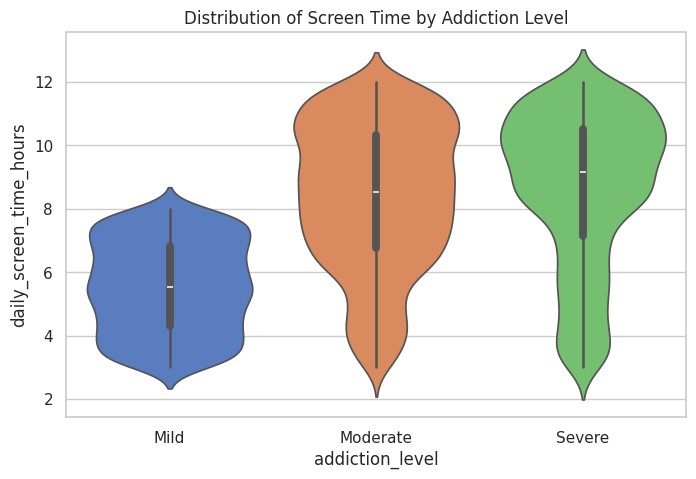

In [31]:
plt.figure(figsize=(8,5))
sns.violinplot(
    x='addiction_level',
    y='daily_screen_time_hours',
    palette="muted",
    data=df
)
plt.title("Distribution of Screen Time by Addiction Level")
plt.show()

## Feature engineering

In [32]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
data = df.dropna()

In [34]:
le = LabelEncoder()
categorical_cols = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [35]:
X = data.drop(['transaction_id', 'user_id', 'addicted_label'], axis=1)
y = data['addicted_label']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}


In [39]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000
KNN Accuracy: 0.9910
Naive Bayes Accuracy: 1.0000
Gradient Boosting Accuracy: 1.0000
AdaBoost Accuracy: 1.0000


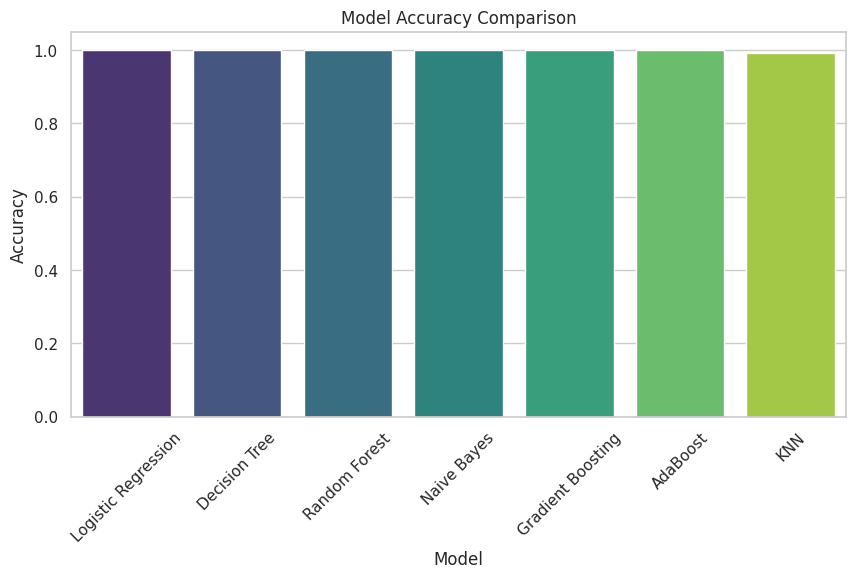

In [40]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()


Best Model: Logistic Regression

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       265
           1       1.00      1.00      1.00      1072

    accuracy                           1.00      1337
   macro avg       1.00      1.00      1.00      1337
weighted avg       1.00      1.00      1.00      1337



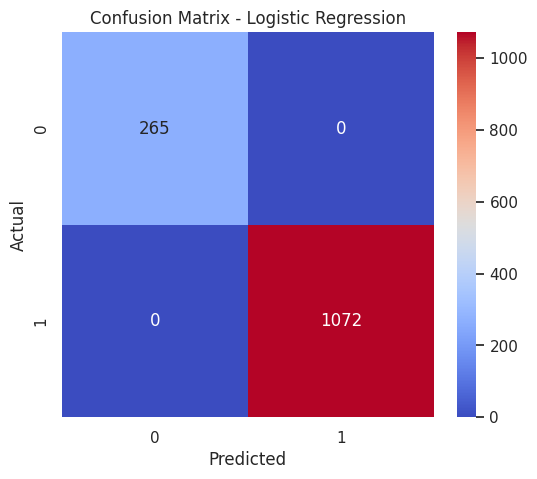

In [41]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Thank you...pls upvote!!!!!!!!
